# Matrix-Free GP Regression with Implicit Kernel Operators

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/matrix_free_gp.ipynb)

For large $N$, forming the $N \times N$ kernel matrix costs $O(N^2)$ memory and a dense factorization costs $O(N^3)$ time. kernellib's `ImplicitKernelOperator` never forms the matrix: it computes $(K + \sigma^2 I)\,v$ on the fly, one kernel row at a time, in $O(N)$ memory. Because it is a lineax operator with its structural predicates registered, every gaussx solver strategy works on it unchanged.

**What you'll learn:**

1. Turning a kernel object into a matrix-free operator with `kl.to_operator(..., implicit=True)`
2. Solving kernel systems with gaussx's `CGSolver`, `PreconditionedCGSolver` and `BBMMSolver`
3. What structural tags do, and when you must set them yourself
4. Exploiting orthonormal low-rank structure with `gaussx.LowRankUpdate`
5. GP prediction: matrix-free vs dense

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import gaussx as gx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import kernellib as kl


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,gaussx,matplotlib,kernellib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.17.1

jax       : 0.11.2
gaussx    : 0.1.0
matplotlib: 3.11.2
kernellib : 0.0.3

Compiler    : Clang 20.1.4 
OS          : Linux
Release     : 6.18.44-fc-v37
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## Data

A 1-D GP regression problem with $N = 2000$ noisy observations of a smooth function.

In [4]:
N = 2000
noise_var = 0.1

key_x, key_noise = jax.random.split(jax.random.PRNGKey(42))
X_train = jnp.sort(jax.random.uniform(key_x, (N, 1), minval=-5.0, maxval=5.0), axis=0)
f_true = jnp.sin(X_train[:, 0]) + 0.2 * jnp.cos(3.0 * X_train[:, 0])
y_train = f_true + jnp.sqrt(noise_var) * jax.random.normal(key_noise, (N,))

print(f"Training set: N = {N}, D = {X_train.shape[1]}, noise variance = {noise_var}")

Training set: N = 2000, D = 1, noise variance = 0.1


## From a kernel to a matrix-free operator

We use an RBF kernel,

$$k(x, x') = \sigma_f^2 \exp\!\left(-\frac{\|x - x'\|^2}{2 \ell^2}\right)$$

`kl.to_operator(kernel, X, noise=..., implicit=True)` returns an `ImplicitKernelOperator` for $K + \sigma_n^2 I$ with the noise fused in. It splits the kernel's arrays out as the operator's `params`, so gradients with respect to the hyperparameters flow through the operator's custom JVP, and it tags the result symmetric and positive semidefinite.

In [5]:
kernel = kl.RBF(lengthscale=1.0, variance=1.0)
op = kl.to_operator(kernel, X_train, noise=noise_var, implicit=True)

print(f"Operator: {type(op).__name__}, {op.in_size()} x {op.out_size()}")

Operator: ImplicitKernelOperator, 2000 x 2000


The operator supports `mv` for iterative solvers. `as_matrix()` exists for debugging, but it materializes the full $N \times N$ matrix, which is exactly what we avoid at scale. Here we build it once to validate the matvec and serve as the dense baseline.

In [6]:
v = jax.random.normal(jax.random.PRNGKey(0), (N,))
mv_implicit = op.mv(v)

K_dense = op.as_matrix()  # validation only
mv_err = jnp.max(jnp.abs(mv_implicit - K_dense @ v))
print(f"Matvec error (implicit vs dense): {mv_err:.2e}")

Matvec error (implicit vs dense): 5.15e-14


## Solving with `CGSolver`

`gaussx.CGSolver` uses lineax CG for the solve $(K + \sigma_n^2 I)\,\alpha = y$ and stochastic Lanczos quadrature (SLQ) for the log-determinant. Both need only matvecs.

In [7]:
cg = gx.CGSolver(rtol=1e-6, atol=1e-6, max_steps=200, num_probes=30)
alpha_cg = cg.solve(op, y_train)
print(f"CG solve residual: {jnp.max(jnp.abs(op.mv(alpha_cg) - y_train)):.2e}")

logdet_cg = cg.logdet(op, key=jax.random.PRNGKey(0))
logdet_dense = jnp.linalg.slogdet(K_dense)[1]
print(f"CG stochastic logdet: {logdet_cg:.4f}")
print(f"Dense logdet:         {logdet_dense:.4f}")
rel_err = jnp.abs(logdet_cg - logdet_dense) / jnp.abs(logdet_dense)
print(f"Relative error:       {rel_err:.2e}")

CG solve residual: 2.45e-07


CG stochastic logdet: -4522.7308
Dense logdet:         -4522.1695


Relative error:       1.24e-04


## Solving with `PreconditionedCGSolver`

A rank-$k$ partial Cholesky preconditioner cuts the number of CG iterations on ill-conditioned kernel systems. The `shift` should match the noise variance.

In [8]:
pcg = gx.PreconditionedCGSolver(
    preconditioner_rank=30, shift=noise_var, rtol=1e-6, atol=1e-6
)
alpha_pcg = pcg.solve(op, y_train)
print(f"Preconditioned CG residual: {jnp.max(jnp.abs(op.mv(alpha_pcg) - y_train)):.2e}")

Preconditioned CG residual: 5.93e-08


## Solving with `BBMMSolver`

`gaussx.BBMMSolver` (Gardner et al., 2018) computes the solve and the log-determinant together with `solve_and_logdet`, sharing the matvecs between them.

In [9]:
bbmm = gx.BBMMSolver(cg_max_iter=200, cg_tolerance=1e-6, lanczos_iter=50, num_probes=20)
alpha_bbmm, logdet_bbmm = bbmm.solve_and_logdet(op, y_train)
print(f"BBMM solve residual: {jnp.max(jnp.abs(op.mv(alpha_bbmm) - y_train)):.2e}")
print(f"BBMM logdet:         {logdet_bbmm:.4f}")
print(f"Dense logdet:        {logdet_dense:.4f}")

BBMM solve residual: 2.45e-07
BBMM logdet:         -4527.8656
Dense logdet:        -4522.1695


### The three solvers agree

In [10]:
print("Max difference between solutions:")
print(f"  CG  vs PCG:  {jnp.max(jnp.abs(alpha_cg - alpha_pcg)):.2e}")
print(f"  CG  vs BBMM: {jnp.max(jnp.abs(alpha_cg - alpha_bbmm)):.2e}")
print(f"  PCG vs BBMM: {jnp.max(jnp.abs(alpha_pcg - alpha_bbmm)):.2e}")

Max difference between solutions:
  CG  vs PCG:  2.06e-06
  CG  vs BBMM: 0.00e+00
  PCG vs BBMM: 2.06e-06


## Structural tags

Tags are claims, not inferences: an operator does not work out for itself that a kernel is symmetric or PSD. `to_operator` sets both tags because every kernel it accepts produces a symmetric PSD Gram matrix. If you build an `ImplicitKernelOperator` directly from a callable, the tags are yours to pass; without them the operator reports no structure and gaussx cannot pick its symmetric or PSD fast paths.

In [11]:
def rbf(x, xp):
    return jnp.exp(-0.5 * jnp.sum((x - xp) ** 2))


untagged = kl.ImplicitKernelOperator(rbf, X_train, noise_var)
tagged = kl.ImplicitKernelOperator(
    rbf,
    X_train,
    noise_var,
    tags=frozenset({lx.symmetric_tag, lx.positive_semidefinite_tag}),
)

for name, o in [("to_operator", op), ("untagged", untagged), ("tagged", tagged)]:
    sym, psd = lx.is_symmetric(o), lx.is_positive_semidefinite(o)
    print(f"{name:<12} symmetric={sym!s:<5} psd={psd}")

to_operator  symmetric=True  psd=True
untagged     symmetric=False psd=False
tagged       symmetric=True  psd=True


## Orthonormal low-rank structure with `LowRankUpdate`

When a truncated SVD of the kernel is available, `gaussx.LowRankUpdate` represents the operator as $L + U \operatorname{diag}(S) V^\top$. Passing `orthonormal=True` opts in to SVD-specific PSD inference for orthonormal factors with non-negative weights. Here $U$ and $V$ come from separate slices of the SVD, so we pass the symmetric and PSD tags explicitly.

We take a dense SVD for demonstration only. In practice $U$, $S$, $V$ would come from a randomized or Nyström method without forming the matrix.

In [12]:
rank = 50
U_full, S_full, Vt_full = jnp.linalg.svd(K_dense - noise_var * jnp.eye(N))

svd_op = gx.LowRankUpdate(
    lx.DiagonalLinearOperator(noise_var * jnp.ones(N)),
    U_full[:, :rank],
    S_full[:rank],
    Vt_full[:rank, :].T,
    tags=frozenset({lx.positive_semidefinite_tag, lx.symmetric_tag}),
    orthonormal=True,
)

alpha_svd = cg.solve(svd_op, y_train)
svd_res = jnp.max(jnp.abs(svd_op.mv(alpha_svd) - y_train))
print(f"Rank-{rank} solve residual: {svd_res:.2e}")
logdet_svd = cg.logdet(svd_op, key=jax.random.PRNGKey(1))
print(f"Rank-{rank} logdet:  {logdet_svd:.4f}")
print(f"Dense logdet:    {logdet_dense:.4f}")

Rank-50 solve residual: 3.61e-07


Rank-50 logdet:  -4528.3541
Dense logdet:    -4522.1695


## GP prediction

With $\alpha = (K + \sigma_n^2 I)^{-1} y$, the posterior mean at test points $X_*$ is

$$\mu_* = K_{*f}\,\alpha$$

The same kernel object builds the cross-covariance $K_{*f}$. We compare the matrix-free CG solution with a dense solve.

In [13]:
X_test = jnp.linspace(-5.5, 5.5, 300)[:, None]
K_star = kernel(X_test, X_train)

mu_cg = K_star @ alpha_cg
mu_dense = K_star @ jnp.linalg.solve(K_dense, y_train)
pred_diff = jnp.max(jnp.abs(mu_cg - mu_dense))
print(f"Max prediction difference (CG vs dense): {pred_diff:.2e}")

Max prediction difference (CG vs dense): 3.01e-07


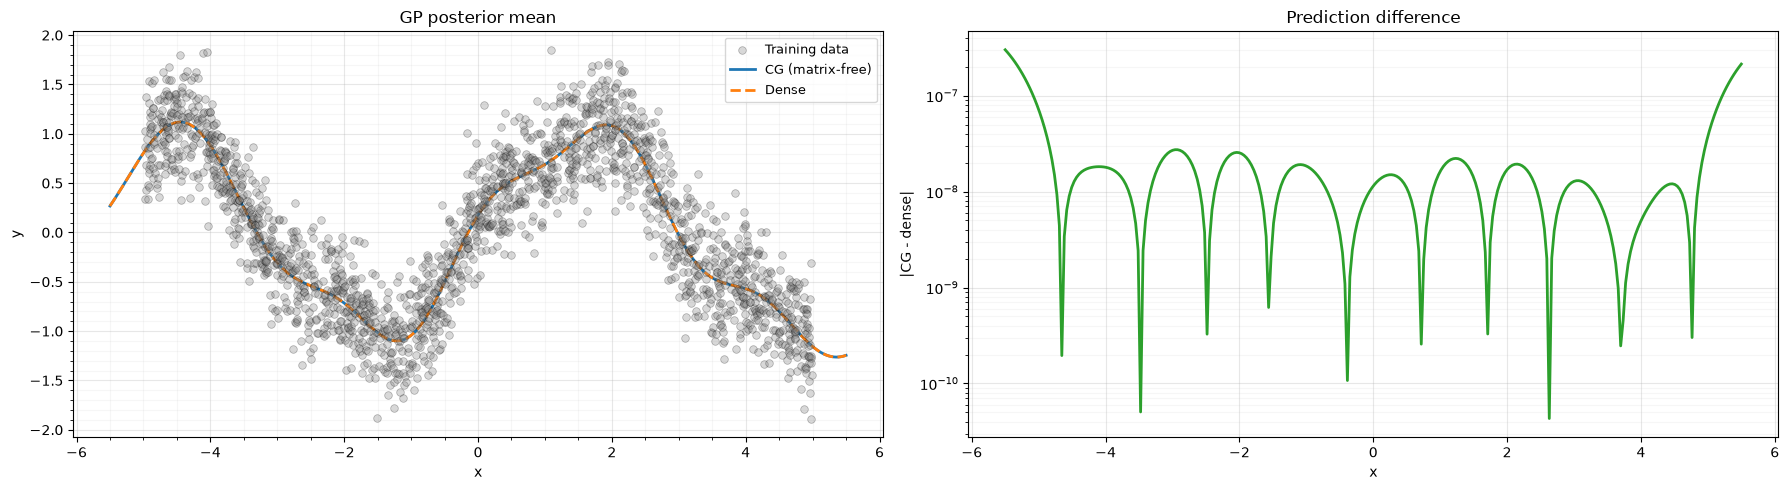

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax = axes[0]
ax.scatter(
    X_train[:, 0],
    y_train,
    s=30,
    alpha=0.3,
    color="gray",
    edgecolors="k",
    linewidths=0.5,
    label="Training data",
    zorder=5,
)
ax.plot(X_test[:, 0], mu_cg, color="C0", lw=2, label="CG (matrix-free)", zorder=3)
ax.plot(X_test[:, 0], mu_dense, "--", color="C1", lw=2, label="Dense", zorder=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("GP posterior mean")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

ax = axes[1]
ax.plot(X_test[:, 0], jnp.abs(mu_cg - mu_dense), color="C2", lw=2)
ax.set_xlabel("x")
ax.set_ylabel("|CG - dense|")
ax.set_title("Prediction difference")
ax.set_yscale("log")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)

plt.tight_layout()
plt.show()

## Summary

- **`kl.to_operator(kernel, X, noise=..., implicit=True)`** gives a matrix-free, correctly tagged $(K + \sigma^2 I)$ in $O(N)$ memory per matvec, with gradients reaching the kernel's hyperparameters.
- **`ImplicitKernelOperator`** can be built from any callable; then the symmetric and PSD tags are yours to set.
- **`gx.CGSolver`** solves with CG and estimates the log-determinant with SLQ from matvecs alone.
- **`gx.PreconditionedCGSolver`** adds a partial Cholesky preconditioner for faster convergence.
- **`gx.BBMMSolver`** computes solve and log-determinant together.
- **`gx.LowRankUpdate(..., orthonormal=True)`** exploits factored low-rank structure directly.

**When to use what:**

- **Small $N$ (below about 5,000):** dense Cholesky, via `kl.to_operator(kernel, X, noise=...)`, is fastest and exact.
- **Medium $N$ (about 5,000 to 50,000):** CG or preconditioned CG on the implicit operator.
- **Large $N$:** BBMM on the implicit operator amortizes matvecs across the solve and log-determinant; add preconditioning if the system is ill-conditioned.
- **Low-rank structure available:** use `LowRankUpdate` directly.